<a href="https://colab.research.google.com/github/Lomada-Sahithi/Machine-Learning-Sem-5/blob/main/K_means_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.utils import shuffle
from PIL import Image
import os

In [2]:
from google.colab import files
uploaded = files.upload()

Saving WhatsApp Image 2024-09-29 at 00.03.52_51f05995.jpg to WhatsApp Image 2024-09-29 at 00.03.52_51f05995.jpg


In [3]:
import os
import shutil

# Original filename (with spaces)
original = '/content/WhatsApp Image 2024-09-29 at 00.03.52_51f05995.jpg'

# New simple filename
new_name = '/content/myimage.jpg'

# Rename
shutil.copy(original, new_name)

print("Original exists:", os.path.exists(original))
print("New file exists:", os.path.exists(new_name))
print("New file size  :", os.path.getsize(new_name), "bytes")

Original exists: True
New file exists: True
New file size  : 237653 bytes


In [4]:
from PIL import Image
import numpy as np

# Load image
img = Image.open('/content/myimage.jpg').convert('RGB')

# Convert to numpy array
img_array = np.array(img)

print("Image mode        :", img.mode)
print("Image size (W, H) :", img.size)
print("Array shape       :", img_array.shape)
print("Data type         :", img_array.dtype)
print("Pixel value range :", img_array.min(), "-", img_array.max())

Image mode        : RGB
Image size (W, H) : (1200, 1600)
Array shape       : (1600, 1200, 3)
Data type         : uint8
Pixel value range : 0 - 255


In [5]:
# Flatten image to (num_pixels, 3)
pixels = img_array.reshape(-1, 3)

print("Original image shape :", img_array.shape)
print("Flattened pixel shape:", pixels.shape)
print("Total pixels         :", pixels.shape[0])
print("\nFirst 5 pixels (RGB):")
print(pixels[:5])

Original image shape : (1600, 1200, 3)
Flattened pixel shape: (1920000, 3)
Total pixels         : 1920000

First 5 pixels (RGB):
[[209 186 155]
 [209 186 155]
 [209 186 155]
 [209 186 155]
 [209 186 155]]


In [6]:
from sklearn.cluster import KMeans
import time

# Number of colors to reduce the image to
K = 16

# Train K-Means
print(f"Training K-Means with K={K} colors...")
start = time.time()

kmeans = KMeans(n_clusters=K, init='k-means++', random_state=42, n_init=10)
kmeans.fit(pixels)

end = time.time()
print(f"Training complete in {end - start:.2f} seconds")
print("\nCluster centers (RGB values of the 16 colors):")
print(kmeans.cluster_centers_.astype(int))

Training K-Means with K=16 colors...
Training complete in 49.97 seconds

Cluster centers (RGB values of the 16 colors):
[[208 189 158]
 [ 74  92  20]
 [118 121 114]
 [210  56  47]
 [ 53  68  17]
 [ 21  21   6]
 [100 121  17]
 [ 69  68  44]
 [180  27  22]
 [205 172 121]
 [129  11   8]
 [138 140  55]
 [217 198 168]
 [155 149 129]
 [ 38  44  15]
 [ 97  94  64]]


In [7]:
# Get cluster label for each pixel
labels = kmeans.labels_

# Replace each pixel with its cluster center color
compressed_pixels = kmeans.cluster_centers_[labels]

# Reshape back to original image shape
compressed_img_array = compressed_pixels.reshape(img_array.shape).astype('uint8')

print("Original image shape :", img_array.shape)
print("Compressed shape     :", compressed_img_array.shape)
print("Unique colors (original)  :", len(np.unique(img_array.reshape(-1, 3), axis=0)))
print("Unique colors (compressed):", len(np.unique(compressed_img_array.reshape(-1, 3), axis=0)))

Original image shape : (1600, 1200, 3)
Compressed shape     : (1600, 1200, 3)
Unique colors (original)  : 195809
Unique colors (compressed): 16


In [9]:
from PIL import Image
import os

# --- Method 1: Reduce JPEG quality (no K-Means) ---
Image.fromarray(img_array).save('/content/m1_low_quality.jpg', quality=30)
m1_size = os.path.getsize('/content/m1_low_quality.jpg') / 1024

# --- Method 2: K-Means (K=16) + JPEG quality 30 ---
Image.fromarray(compressed_img_array).save('/content/m2_kmeans_jpg.jpg', quality=30)
m2_size = os.path.getsize('/content/m2_kmeans_jpg.jpg') / 1024

# --- Method 3: K-Means (K=16) + PNG palette (indexed) ---
comp_img = Image.fromarray(compressed_img_array)
comp_palette = comp_img.convert('P', palette=Image.ADAPTIVE, colors=16)
comp_palette.save('/content/m3_kmeans_palette.png', optimize=True)
m3_size = os.path.getsize('/content/m3_kmeans_palette.png') / 1024

# --- Original file size (as uploaded) ---
orig_size = os.path.getsize('/content/myimage.jpg') / 1024

# --- Comparison table ---
print(f"{'Method':<40} {'Size (KB)':>10} {'Reduction':>12}")
print("-" * 65)
print(f"{'Original (uploaded JPG)':<40} {orig_size:>10.1f} {'—':>12}")
print(f"{'M1: Low-quality JPG (q30)':<40} {m1_size:>10.1f} {(1-m1_size/orig_size)*100:>11.1f}%")
print(f"{'M2: K-Means (K=16) + JPG (q30)':<40} {m2_size:>10.1f} {(1-m2_size/orig_size)*100:>11.1f}%")
print(f"{'M3: K-Means (K=16) + PNG palette':<40} {m3_size:>10.1f} {(1-m3_size/orig_size)*100:>11.1f}%")

Method                                    Size (KB)    Reduction
-----------------------------------------------------------------
Original (uploaded JPG)                       232.1            —
M1: Low-quality JPG (q30)                     114.0        50.9%
M2: K-Means (K=16) + JPG (q30)                119.1        48.7%
M3: K-Means (K=16) + PNG palette              232.1        -0.0%


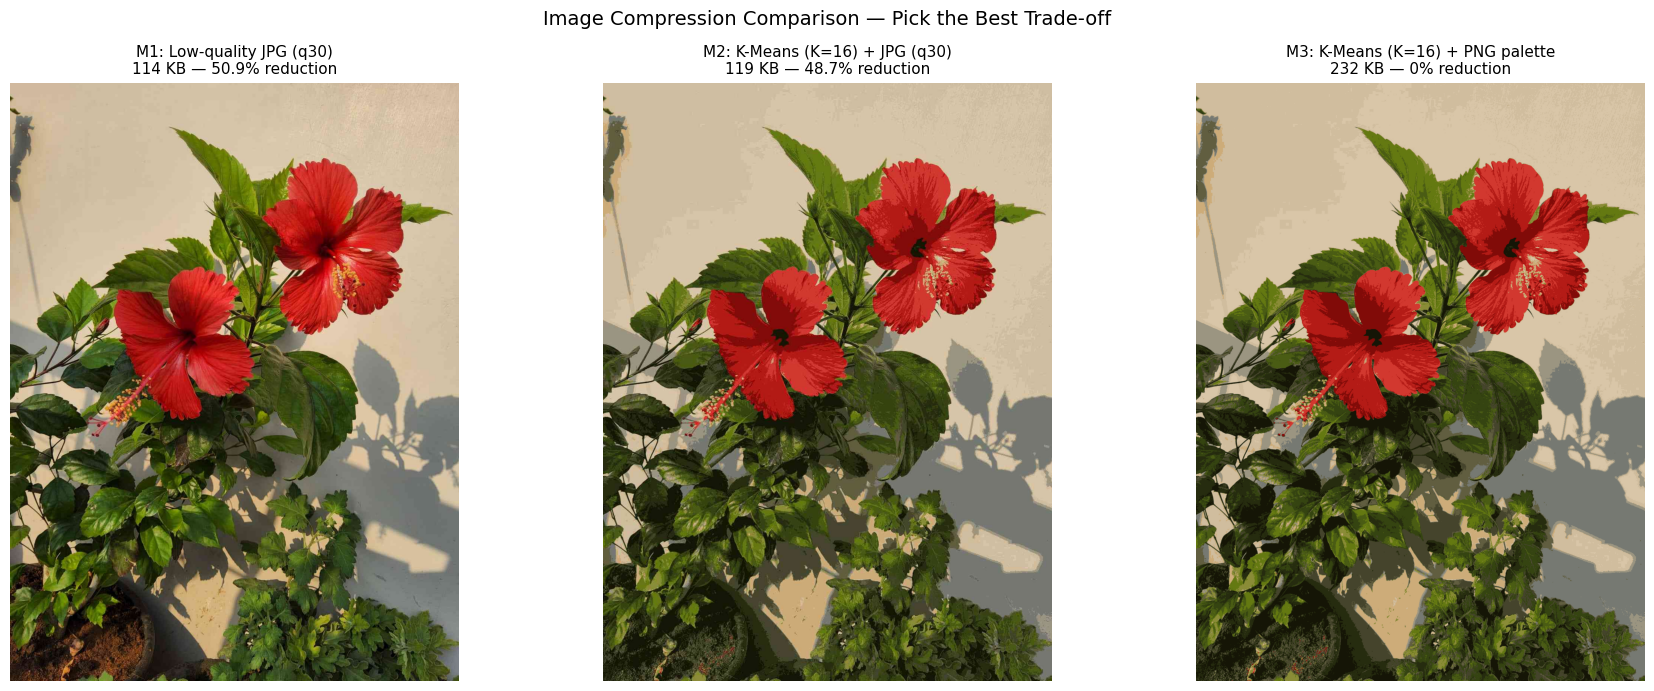

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

# Load the three compressed versions
m1 = Image.open('/content/m1_low_quality.jpg')
m2 = Image.open('/content/m2_kmeans_jpg.jpg')
m3 = Image.open('/content/m3_kmeans_palette.png')

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

axes[0].imshow(m1)
axes[0].set_title(f'M1: Low-quality JPG (q30)\n114 KB — 50.9% reduction', fontsize=11)
axes[0].axis('off')

axes[1].imshow(m2)
axes[1].set_title(f'M2: K-Means (K=16) + JPG (q30)\n119 KB — 48.7% reduction', fontsize=11)
axes[1].axis('off')

axes[2].imshow(m3)
axes[2].set_title(f'M3: K-Means (K=16) + PNG palette\n232 KB — 0% reduction', fontsize=11)
axes[2].axis('off')

plt.suptitle('Image Compression Comparison — Pick the Best Trade-off', fontsize=14)
plt.tight_layout()
plt.show()

K=  2:    74.6 KB  (reduction:  67.9%)  [0.4s]
K=  4:    95.2 KB  (reduction:  59.0%)  [0.4s]
K=  8:   116.2 KB  (reduction:  49.9%)  [0.5s]
K= 16:   116.8 KB  (reduction:  49.7%)  [0.5s]
K= 32:   119.5 KB  (reduction:  48.5%)  [0.8s]
K= 64:   119.0 KB  (reduction:  48.7%)  [0.9s]


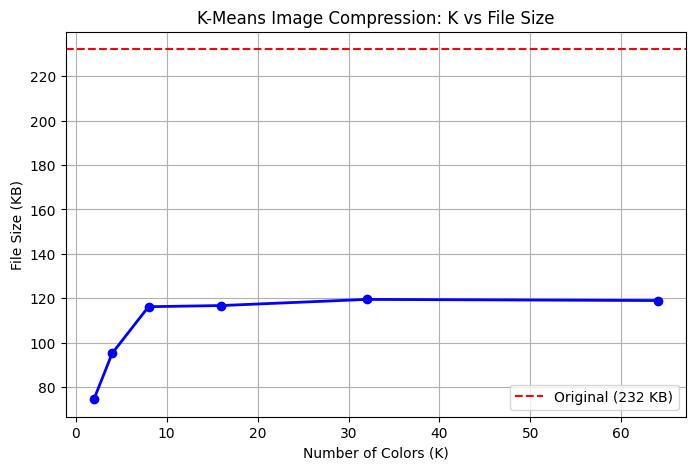

In [12]:
from sklearn.cluster import MiniBatchKMeans
from PIL import Image
import numpy as np
import os
import time

# Sample 50,000 pixels (random subset) for faster training
np.random.seed(42)
sample_idx = np.random.choice(len(pixels), 50000, replace=False)
pixels_sample = pixels[sample_idx]

k_values = [2, 4, 8, 16, 32, 64]
results = []

for k in k_values:
    start = time.time()

    # Train on the SAMPLE (fast)
    km = MiniBatchKMeans(n_clusters=k, init='k-means++', random_state=42, n_init=3, batch_size=1024)
    km.fit(pixels_sample)

    # Predict on FULL image (still fast)
    labels = km.predict(pixels)
    compressed = km.cluster_centers_[labels].reshape(img_array.shape).astype('uint8')

    # Save as JPG q30
    path = f'/content/kmeans_k{k}.jpg'
    Image.fromarray(compressed).save(path, quality=30)
    size = os.path.getsize(path) / 1024
    results.append((k, size))

    elapsed = time.time() - start
    print(f"K={k:>3}: {size:>7.1f} KB  (reduction: {(1-size/orig_size)*100:>5.1f}%)  [{elapsed:.1f}s]")

# Plot K vs file size
ks = [r[0] for r in results]
sizes = [r[1] for r in results]

plt.figure(figsize=(8, 5))
plt.plot(ks, sizes, marker='o', color='blue', linewidth=2)
plt.axhline(y=orig_size, color='red', linestyle='--', label=f'Original ({orig_size:.0f} KB)')
plt.xlabel('Number of Colors (K)')
plt.ylabel('File Size (KB)')
plt.title('K-Means Image Compression: K vs File Size')
plt.grid(True)
plt.legend()
plt.show()

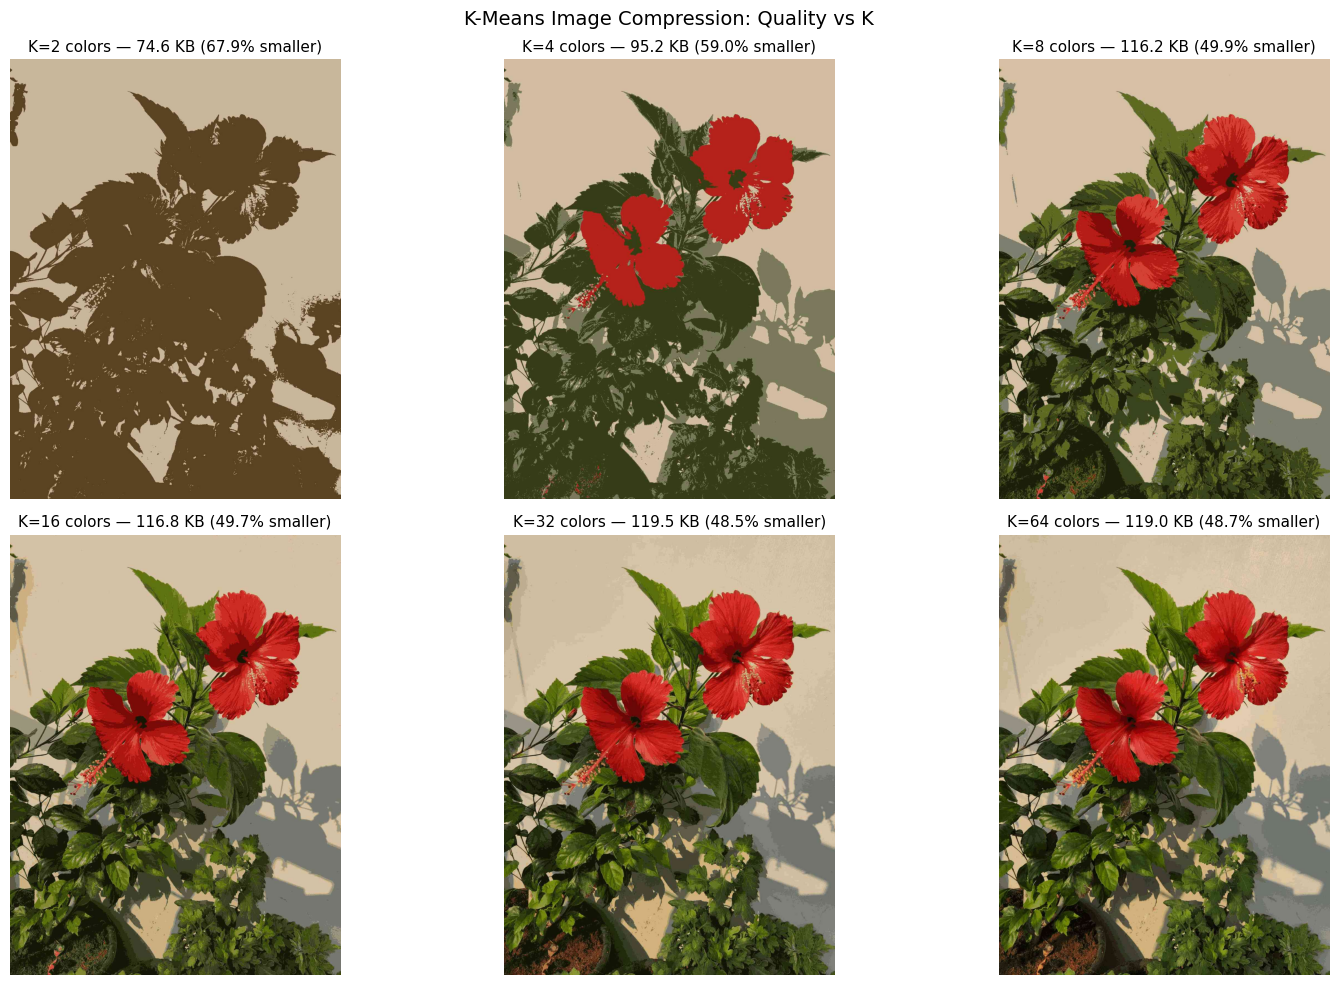

In [13]:
import matplotlib.pyplot as plt
from PIL import Image

k_values = [2, 4, 8, 16, 32, 64]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, k in enumerate(k_values):
    img = Image.open(f'/content/kmeans_k{k}.jpg')
    size = os.path.getsize(f'/content/kmeans_k{k}.jpg') / 1024

    ax = axes[i // 3, i % 3]
    ax.imshow(img)
    ax.set_title(f'K={k} colors — {size:.1f} KB ({(1-size/orig_size)*100:.1f}% smaller)', fontsize=11)
    ax.axis('off')

plt.suptitle('K-Means Image Compression: Quality vs K', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
from PIL import Image
import os

# Load the K=16 compressed version
final_compressed = Image.open('/content/kmeans_k16.jpg')

# Save with a clear name
final_compressed.save('/content/FINAL_compressed_k16.jpg', quality=30)

orig_size = os.path.getsize('/content/myimage.jpg') / 1024
final_size = os.path.getsize('/content/FINAL_compressed_k16.jpg') / 1024

print("=" * 55)
print("         EXERCISE 10.6 — FINAL RESULT")
print("=" * 55)
print(f"Original image size      : {orig_size:.1f} KB")
print(f"Compressed image size    : {final_size:.1f} KB")
print(f"Size reduction           : {(1-final_size/orig_size)*100:.1f}%")
print(f"Colors before            : 195,809")
print(f"Colors after (K=16)      : 16")
print(f"Color reduction factor   : {195809/16:.0f}×")
print("=" * 55)
print("\n✅ K-Means image compression complete!")

         EXERCISE 10.6 — FINAL RESULT
Original image size      : 232.1 KB
Compressed image size    : 116.7 KB
Size reduction           : 49.7%
Colors before            : 195,809
Colors after (K=16)      : 16
Color reduction factor   : 12238×

✅ K-Means image compression complete!


In [15]:
from google.colab import files
files.download('/content/FINAL_compressed_k16.jpg')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>